## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import pickle

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'
NUTS2_LOWER = 'veneto'

In [4]:
YEAR = 2023
MONTH = 'September'
PERIOD = '1st'

In [5]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_{YEAR}-{MONTH}-{PERIOD}_filled.csv', encoding=enc)
#wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Timeline_2022.csv', encoding=enc)

In [6]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,abano terme,veneto,11.79324,45.35865,2023-09-01,2023,9,2023-08-31,45.358184,11.792634,0.368637,0.061493,-0.335046,-0.061493,0.500961,0.213121,-0.413388,-0.213121,0.000000,0.000000,0.000000,0.000000,2023-09-01,45.358184,11.792634,15134.0,14640.0,45.358184,11.792634,14038.800000,13687.500000,14061.500000,13617.923077,14575.785714,13973.818182,14732.538462,14005.000000,2023-09-01,45.350207,11.750054,1565.197734,2023-08-25,2023-08-18,2023-08-25,2023-08-18,88.565837,104.261956
1,adria,veneto,12.05470,45.07423,2023-09-01,2023,9,2023-08-31,45.075215,12.053145,0.500688,0.167782,-0.399615,-0.167782,0.565890,0.188884,-0.504453,-0.188884,0.135968,0.113098,0.109097,0.113098,2023-09-01,45.075215,12.053145,15074.0,14570.0,45.075215,12.053145,13962.750000,13738.142857,14045.700000,13574.000000,14485.384615,13873.500000,14705.133333,13907.700000,2023-09-01,45.050206,12.050055,1600.968009,2023-08-25,2023-08-18,2023-08-25,2023-08-18,35.338686,37.967628
2,adria,veneto,12.05470,45.05177,2023-09-01,2023,9,2023-08-31,45.052757,12.053145,0.195560,-0.061507,-0.212984,0.061507,0.280443,-0.014148,-0.283133,0.014148,0.097824,0.082140,0.068815,0.082140,2023-09-01,45.052757,12.053145,15182.0,14859.0,45.052757,12.053145,14026.625000,13725.666667,14086.555556,13647.769231,14516.307692,13914.214286,14767.923077,14010.444444,2023-09-01,45.050206,12.050055,1600.968009,2023-08-25,2023-08-18,2023-08-25,2023-08-18,35.338686,37.967628
3,adria,veneto,12.02294,45.07423,2023-09-01,2023,9,2023-08-31,45.075215,12.021704,0.425540,0.093154,-0.363668,-0.093154,0.552185,0.212779,-0.476087,-0.212779,0.129311,0.112715,0.109503,0.112715,2023-09-01,45.075215,12.021704,15043.0,14556.0,45.075215,12.021704,13943.400000,13660.833333,14079.818182,13539.769231,14513.187500,13843.600000,14799.533333,13931.100000,2023-09-01,45.050206,12.050055,1600.968009,2023-08-25,2023-08-18,2023-08-25,2023-08-18,35.338686,37.967628
4,adria,veneto,11.99118,45.07423,2023-09-01,2023,9,2023-08-31,45.075215,11.990263,0.336007,-0.009908,-0.284490,0.009908,0.510258,0.141104,-0.457069,-0.141104,0.124480,0.120057,0.100504,0.120057,2023-09-01,45.075215,11.990263,15073.0,14486.0,45.075215,11.990263,13961.777778,13664.500000,14126.900000,13532.692308,14504.625000,13860.928571,14819.400000,13925.777778,2023-09-01,45.050206,11.950055,1525.277576,2023-08-25,2023-08-18,2023-08-25,2023-08-18,26.485647,27.840720


In [7]:
#wnv_file.head()

In [8]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [9]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [10]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,abano terme,veneto,11.79324,45.35865,2023-09-01,2023,9,0.368637,0.061493,-0.335046,-0.061493,0.500961,0.213121,-0.413388,-0.213121,0.000000,0.000000,0.000000,0.000000,15134.0,14640.0,14038.800000,13687.500000,14061.500000,13617.923077,14575.785714,13973.818182,14732.538462,14005.000000,1565.197734,88.565837,104.261956
1,adria,veneto,12.05470,45.07423,2023-09-01,2023,9,0.500688,0.167782,-0.399615,-0.167782,0.565890,0.188884,-0.504453,-0.188884,0.135968,0.113098,0.109097,0.113098,15074.0,14570.0,13962.750000,13738.142857,14045.700000,13574.000000,14485.384615,13873.500000,14705.133333,13907.700000,1600.968009,35.338686,37.967628
2,adria,veneto,12.05470,45.05177,2023-09-01,2023,9,0.195560,-0.061507,-0.212984,0.061507,0.280443,-0.014148,-0.283133,0.014148,0.097824,0.082140,0.068815,0.082140,15182.0,14859.0,14026.625000,13725.666667,14086.555556,13647.769231,14516.307692,13914.214286,14767.923077,14010.444444,1600.968009,35.338686,37.967628
3,adria,veneto,12.02294,45.07423,2023-09-01,2023,9,0.425540,0.093154,-0.363668,-0.093154,0.552185,0.212779,-0.476087,-0.212779,0.129311,0.112715,0.109503,0.112715,15043.0,14556.0,13943.400000,13660.833333,14079.818182,13539.769231,14513.187500,13843.600000,14799.533333,13931.100000,1600.968009,35.338686,37.967628
4,adria,veneto,11.99118,45.07423,2023-09-01,2023,9,0.336007,-0.009908,-0.284490,0.009908,0.510258,0.141104,-0.457069,-0.141104,0.124480,0.120057,0.100504,0.120057,15073.0,14486.0,13961.777778,13664.500000,14126.900000,13532.692308,14504.625000,13860.928571,14819.400000,13925.777778,1525.277576,26.485647,27.840720


In [11]:
#wnv_file.head(5)

### Merge Timeline and WNV Case Files ###

In [12]:
# ## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_timeline:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")


In [13]:
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('barbarano vicentino','barbarano mossano'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('biancade','roncade'))
# wnv_file.drop(wnv_file[(wnv_file['lau1'] == 'brescia')].index , inplace=True)
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('castelnuovo bariano','castelnovo bariano'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('frassinelle','frassinelle polesine'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('giacciano in barucchella','giacciano con baruchella'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('godega saint urbano','godega da saint urbano'))
# wnv_file.drop(wnv_file[(wnv_file['lau1'] == 'localita ca barzoni')].index , inplace=True)
# wnv_file.drop(wnv_file[(wnv_file['lau1'] == 'mantova')].index , inplace=True)
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('marghera','venezia'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('masera','masera da padova'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('mestre','venezia'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('monastier','monastier da treviso'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('monteforte','monteforte da alpone'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('montegrotto','montegrotto terme'))
# wnv_file.drop(wnv_file[(wnv_file['lau1'] == 'palermo')].index , inplace=True)
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('pra maggiore','pramaggiore'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint elena da silea','saint elena'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint pietri viminario','saint pietro viminario'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint pietro morubio','saint pietro da morubio'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint pietro da morubi','saint pietro da morubio'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('selvazzano','selvazzano dentro'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('vialeggio sul mincio','valeggio sul mincio'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('vo euganeo','vo'))


In [14]:
# ## Check again

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_timeline:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [15]:
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint pietro da morubioo','saint pietro da morubio'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('selvazzano dentro dentro','selvazzano dentro'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('masera da padovada sul piave','masera da padova'))

In [16]:
# ## Check again

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_timeline:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [17]:
# merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )
merged = timeline_file

In [18]:
# merged

In [19]:
# merged = fillna(merged,{'case': 0})
merged['case'] = 0

In [20]:
merged['case'].value_counts()

0    903
Name: case, dtype: int64

In [21]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2023-09-01,abano terme,veneto,11.793240,45.358650,2023.0,9.0,0.368637,0.061493,-0.335046,-0.061493,0.500961,0.213121,-0.413388,-0.213121,0.000000,0.000000,0.000000,0.000000,15134.0,14640.0,14038.800000,13687.500000,14061.500000,13617.923077,14575.785714,13973.818182,14732.538462,14005.000000,1565.197734,88.565837,104.261956,0.0
1,2023-09-01,adria,veneto,12.041994,45.065246,2023.0,9.0,0.329892,0.006074,-0.303029,-0.006074,0.452057,0.107604,-0.413797,-0.107604,0.128406,0.120407,0.098023,0.120407,15104.0,14610.4,13976.360556,13697.928571,14081.319747,13577.953846,14493.927628,13871.077143,14749.322949,13939.382222,1585.829922,33.568078,35.942247,0.0
2,2023-09-01,affi,veneto,10.776730,45.556800,2023.0,9.0,0.353597,0.073092,-0.332336,-0.073092,0.468483,0.136305,-0.403213,-0.136305,0.129653,0.068415,0.093486,0.068415,15332.0,14942.0,13948.583333,13694.400000,14089.076923,13693.533333,14517.882353,13856.687500,14603.421053,14001.444444,1584.392692,195.303170,213.205983,0.0
3,2023-09-01,agna,veneto,11.965390,45.175310,2023.0,9.0,0.320171,0.025688,-0.319857,-0.025688,0.465004,0.142796,-0.417618,-0.142796,0.128642,0.105475,0.092688,0.105475,15084.0,14553.0,13901.000000,13688.000000,14045.111111,13555.769231,14447.058824,13863.700000,14736.428571,13913.461538,1532.337837,28.383700,31.619082,0.0
4,2023-09-01,agordo,veneto,12.047550,46.302970,2023.0,9.0,0.741232,0.323687,-0.627098,-0.323687,0.640572,0.351151,-0.508889,-0.351151,0.061364,0.054556,0.084401,0.054556,14682.0,14207.0,13753.571429,13453.615385,13938.666667,13542.600000,14121.769231,13607.583333,14234.727273,13679.727273,1535.846290,66.013478,101.374931,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2023-09-01,zevio,veneto,11.133720,45.360710,2023.0,9.0,0.385979,0.108018,-0.330255,-0.108018,0.454926,0.103473,-0.389330,-0.103473,0.067725,0.044294,0.047104,0.044294,15474.5,14875.5,13992.568182,13614.898990,14092.475000,13602.595588,14606.361607,13897.423077,14735.149038,13974.412698,1394.040558,122.043310,142.912284,0.0
567,2023-09-01,zimella,veneto,11.358050,45.347770,2023.0,9.0,0.243030,-0.039182,-0.288759,0.039182,0.348664,0.074104,-0.336464,-0.074104,0.153808,0.104715,0.100736,0.104715,15616.0,14937.0,13951.833333,13646.875000,14134.750000,13579.470588,14628.500000,13841.083333,14812.846154,13966.818182,1414.350506,92.196254,111.336172,0.0
568,2023-09-01,zoppe da cadore,veneto,12.178780,46.388350,2023.0,9.0,0.605675,0.281434,-0.513935,-0.281434,0.416134,0.311667,-0.320716,-0.311667,0.085287,0.014409,0.080532,0.014409,14470.0,14194.0,13558.750000,13380.200000,13821.000000,13474.500000,13965.090909,13587.615385,13984.250000,13584.692308,1569.161136,72.043143,115.127452,0.0
569,2023-09-01,zovencedo,veneto,11.494300,45.437980,2023.0,9.0,0.681957,0.239500,-0.560083,-0.239500,0.273585,0.297118,-0.166500,-0.297118,0.000000,0.000000,0.000000,0.000000,15295.0,14947.0,13962.428571,13718.272727,14065.416667,13746.400000,14417.647059,13981.916667,14529.705882,13987.400000,1328.011342,87.998151,92.987619,0.0


In [22]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset = dataset.astype({'case': 'int'})
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)
lau1_map = lau1_mapping(dataset, 0, 0)

In [23]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

### Add mosqutio predictions using trained model ###

In [24]:
model = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Scaler.pkl', 'rb'))

In [25]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [26]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [27]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [28]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [29]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [30]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [31]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

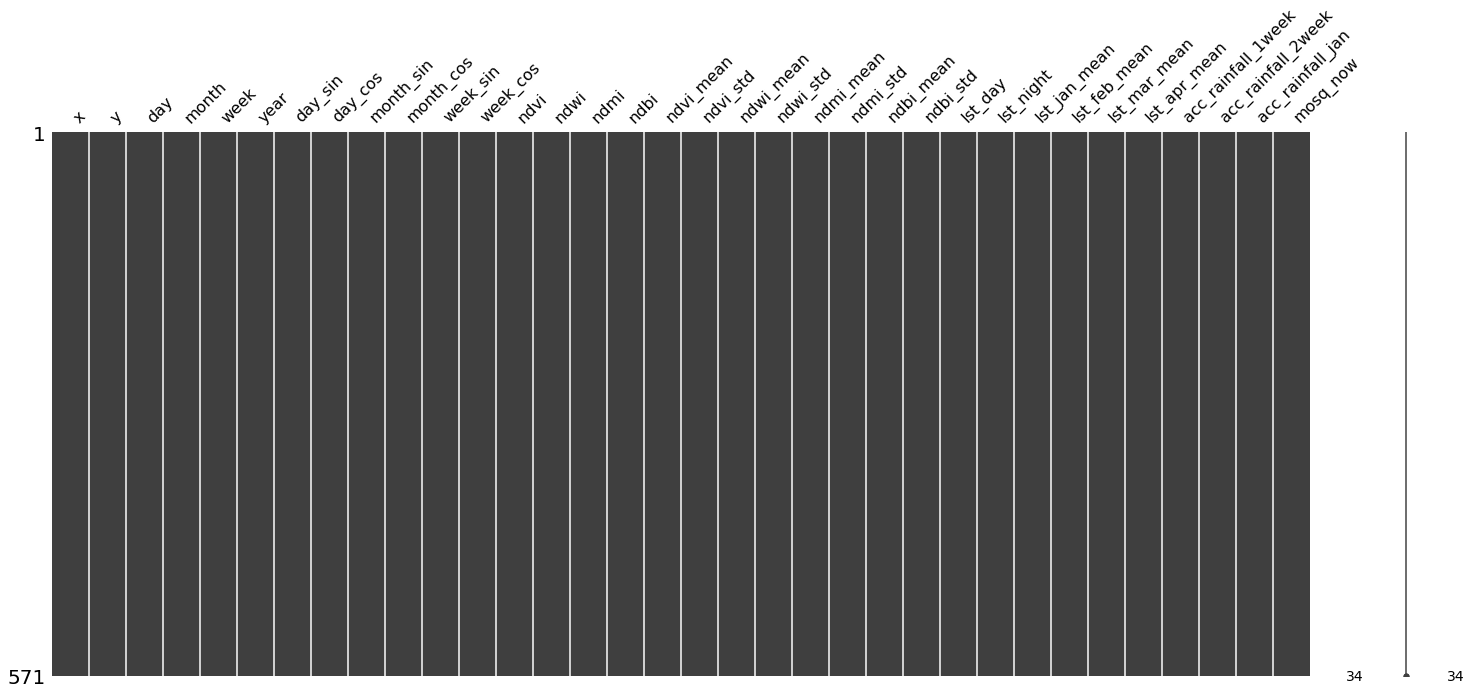

In [32]:
missingno.matrix(dataset_mamoth)

In [33]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [34]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [35]:
predictions = give_predictions(model, dataset_mamoth)

In [36]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,11.79324,45.35865,2023-09-01,19
1,12.04199,45.06525,2023-09-01,19
2,10.77673,45.55680,2023-09-01,26
3,11.96539,45.17531,2023-09-01,24
4,12.04755,46.30297,2023-09-01,18
...,...,...,...,...
566,11.13372,45.36071,2023-09-01,23
567,11.35805,45.34777,2023-09-01,41
568,12.17878,46.38835,2023-09-01,26
569,11.49430,45.43798,2023-09-01,78


In [37]:
#This cell writes the mosquito predictions to a seperate .csv file

# mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2010-2022.csv', index = False)

In [38]:
mosqutio_predictions['dt_placement'] = pd.to_datetime(mosqutio_predictions['dt_placement'])
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

dataset['x.approx'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y.approx'] = dataset['y'].apply(lambda x : round(x,5))

mosqutio_predictions['x.approx'] = mosqutio_predictions['x'].apply(lambda x : round(x,5))
mosqutio_predictions['y.approx'] = mosqutio_predictions['y'].apply(lambda x : round(x,5))

In [39]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x.approx', 'y.approx', 'dt_placement'])

In [40]:
dataset['distance'] = dataset.apply(lambda row: compute_distance(row, x1='x_x', y1 = 'y_x', x2 = 'x_y', y2 = 'y_y'), axis=1)

In [41]:
dataset.distance.max()

0.0

In [42]:
dataset.drop(columns=['x.approx', 'y.approx', 'x_y', 'y_y', 'distance'], axis=1, inplace=True)
dataset.rename(columns={"x_x": "x", "y_x": "y"}, inplace=True)

In [43]:
dataset.reset_index(inplace=True, drop=True)

<AxesSubplot:>

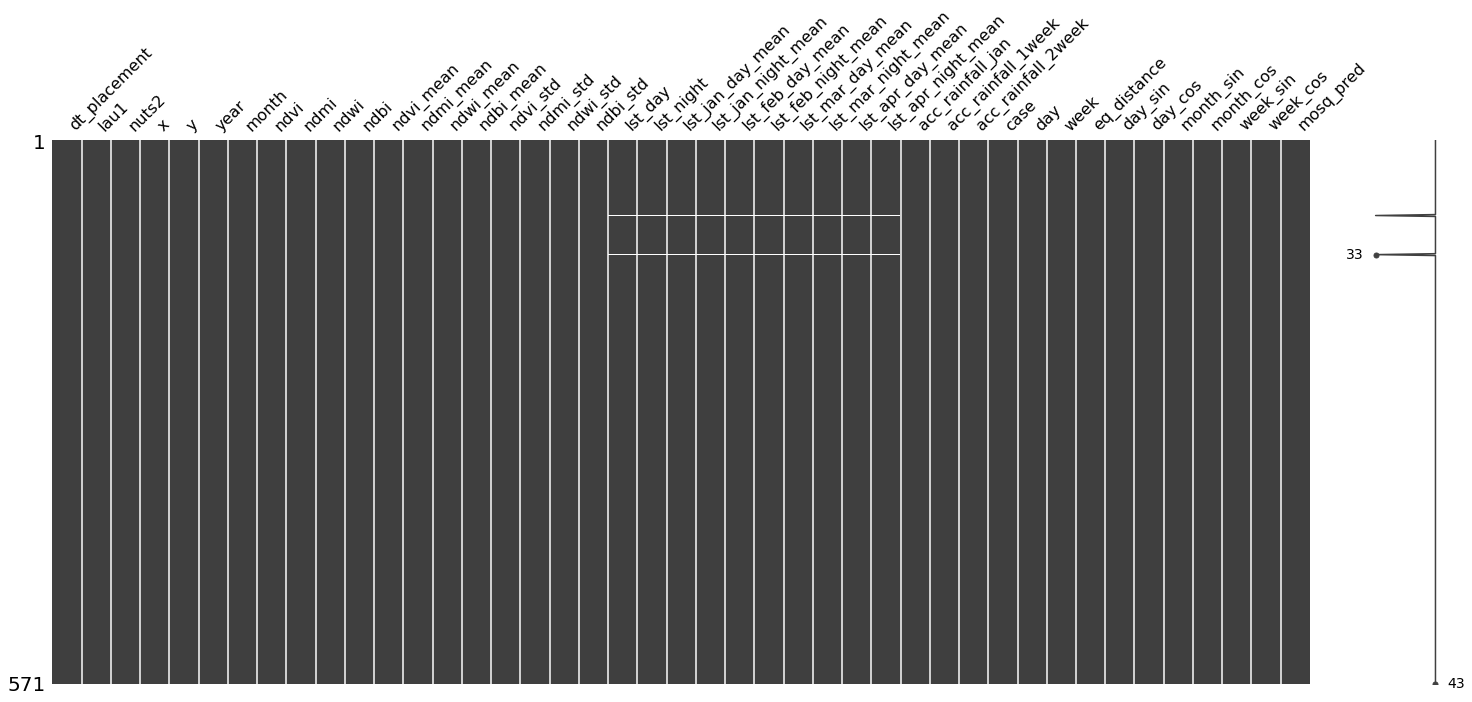

In [44]:
missingno.matrix(dataset)

### Adds demographic features ###

In [45]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [46]:
df_demographics

,lau1,nuts3,nuts2,population
0,abano terme,padova,veneto,"19,349"
1,adria,rovigo,veneto,"20,233"
2,affi,verona,veneto,"2,297"
3,agna,padova,veneto,"3,400"
4,agordo,belluno,veneto,"4,249"
...,...,...,...,...
576,zimella,verona,veneto,"4,834"
577,zoldo alto,belluno,veneto,999
578,zoppe da cadore,belluno,veneto,265
579,zovencedo,vicenza,veneto,796


In [47]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_LOWER}'").copy()

In [48]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [49]:
df_demographics_nuts2

,lau1,population
0,abano terme,"19,349"
1,adria,"20,233"
2,affi,"2,297"
3,agna,"3,400"
4,agordo,"4,249"
...,...,...
576,zimella,"4,834"
577,zoldo alto,999
578,zoppe da cadore,265
579,zovencedo,796


In [50]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['alpago', 'barbarano mossano', 'borgo veneto', 'brenzone sul garda', 'costermano sul garda', 'quero vas', 'val da zoldo', 'val liona']

Length: 8


In [51]:
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'alpago', 'population':6858}, ignore_index=True)
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('mossano','barbarano mossano'))
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'borgo veneto', 'population':7000}, ignore_index=True)
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'brenzone sul garda', 'population':2452}, ignore_index=True)
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('costermano','costermano sul garda'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('quero','quero vas'))
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'val da zoldo', 'population':3242}, ignore_index=True)
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'val liona', 'population':3047}, ignore_index=True)


In [52]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [53]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

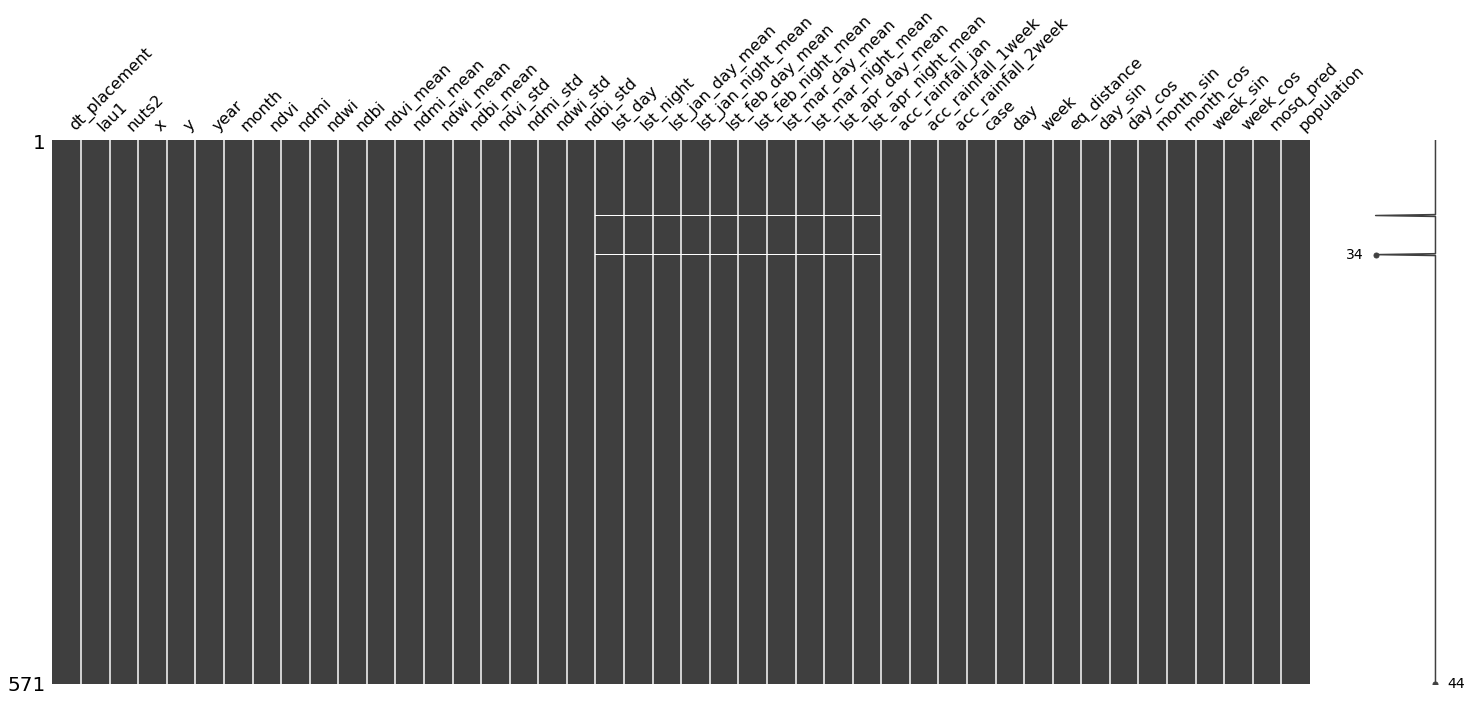

In [54]:
missingno.matrix(dataset)

In [55]:
missing = describe_dataframe(dataset)

In [56]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,population
0,2023-09-01,abano terme,veneto,11.79324,45.35865,2023,9,0.368637,0.061493,-0.335046,-0.061493,0.500961,0.213121,-0.413388,-0.213121,0.000000,0.000000,0.000000,0.000000,15134.0,14640.0,14038.800000,13687.500000,14061.500000,13617.923077,14575.785714,13973.818182,14732.538462,14005.000000,1565.197734,88.565837,104.261956,0,1,35,46.86670,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,19,"19,349"
1,2023-09-01,adria,veneto,12.04199,45.06525,2023,9,0.329892,0.006074,-0.303029,-0.006074,0.452057,0.107604,-0.413797,-0.107604,0.128406,0.120407,0.098023,0.120407,15104.0,14610.4,13976.360556,13697.928571,14081.319747,13577.953846,14493.927628,13871.077143,14749.322949,13939.382222,1585.829922,33.568078,35.942247,0,1,35,46.64640,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,19,"20,233"
2,2023-09-01,affi,veneto,10.77673,45.55680,2023,9,0.353597,0.073092,-0.332336,-0.073092,0.468483,0.136305,-0.403213,-0.136305,0.129653,0.068415,0.093486,0.068415,15332.0,14942.0,13948.583333,13694.400000,14089.076923,13693.533333,14517.882353,13856.687500,14603.421053,14001.444444,1584.392692,195.303170,213.205983,0,1,35,46.81410,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,26,"2,297"
3,2023-09-01,agna,veneto,11.96539,45.17531,2023,9,0.320171,0.025688,-0.319857,-0.025688,0.465004,0.142796,-0.417618,-0.142796,0.128642,0.105475,0.092688,0.105475,15084.0,14553.0,13901.000000,13688.000000,14045.111111,13555.769231,14447.058824,13863.700000,14736.428571,13913.461538,1532.337837,28.383700,31.619082,0,1,35,46.73306,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,24,"3,400"
4,2023-09-01,agordo,veneto,12.04755,46.30297,2023,9,0.741232,0.323687,-0.627098,-0.323687,0.640572,0.351151,-0.508889,-0.351151,0.061364,0.054556,0.084401,0.054556,14682.0,14207.0,13753.571429,13453.615385,13938.666667,13542.600000,14121.769231,13607.583333,14234.727273,13679.727273,1535.846290,66.013478,101.374931,0,1,35,47.84463,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,18,"4,249"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2023-09-01,zevio,veneto,11.13372,45.36071,2023,9,0.385979,0.108018,-0.330255,-0.108018,0.454926,0.103473,-0.389330,-0.103473,0.067725,0.044294,0.047104,0.044294,15474.5,14875.5,13992.568182,13614.898990,14092.475000,13602.595588,14606.361607,13897.423077,14735.149038,13974.412698,1394.040558,122.043310,142.912284,0,1,35,46.70711,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,23,"14,413"
567,2023-09-01,zimella,veneto,11.35805,45.34777,2023,9,0.243030,-0.039182,-0.288759,0.039182,0.348664,0.074104,-0.336464,-0.074104,0.153808,0.104715,0.100736,0.104715,15616.0,14937.0,13951.833333,13646.875000,14134.750000,13579.470588,14628.500000,13841.083333,14812.846154,13966.818182,1414.350506,92.196254,111.336172,0,1,35,46.74854,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,41,"4,834"
568,2023-09-01,zoppe da cadore,veneto,12.17878,46.38835,2023,9,0.605675,0.281434,-0.513935,-0.281434,0.416134,0.311667,-0.320716,-0.311667,0.085287,0.014409,0.080532,0.014409,14470.0,14194.0,13558.750000,13380.200000,13821.000000,13474.500000,13965.090909,13587.615385,13984.250000,13584.692308,1569.161136,72.043143,115.127452,0,1,35,47.96042,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,26,265
569,2023-09-01,zovencedo,veneto,11.49430,45.43798,2023,9,0.681957,0.239500,-0.560083,-0.239500,0.273585,0.297118,-0.166500,-0.297118,0.000000,0.000000,0

In [57]:
dataset = calculate_mosq_previous(dataset)

In [58]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

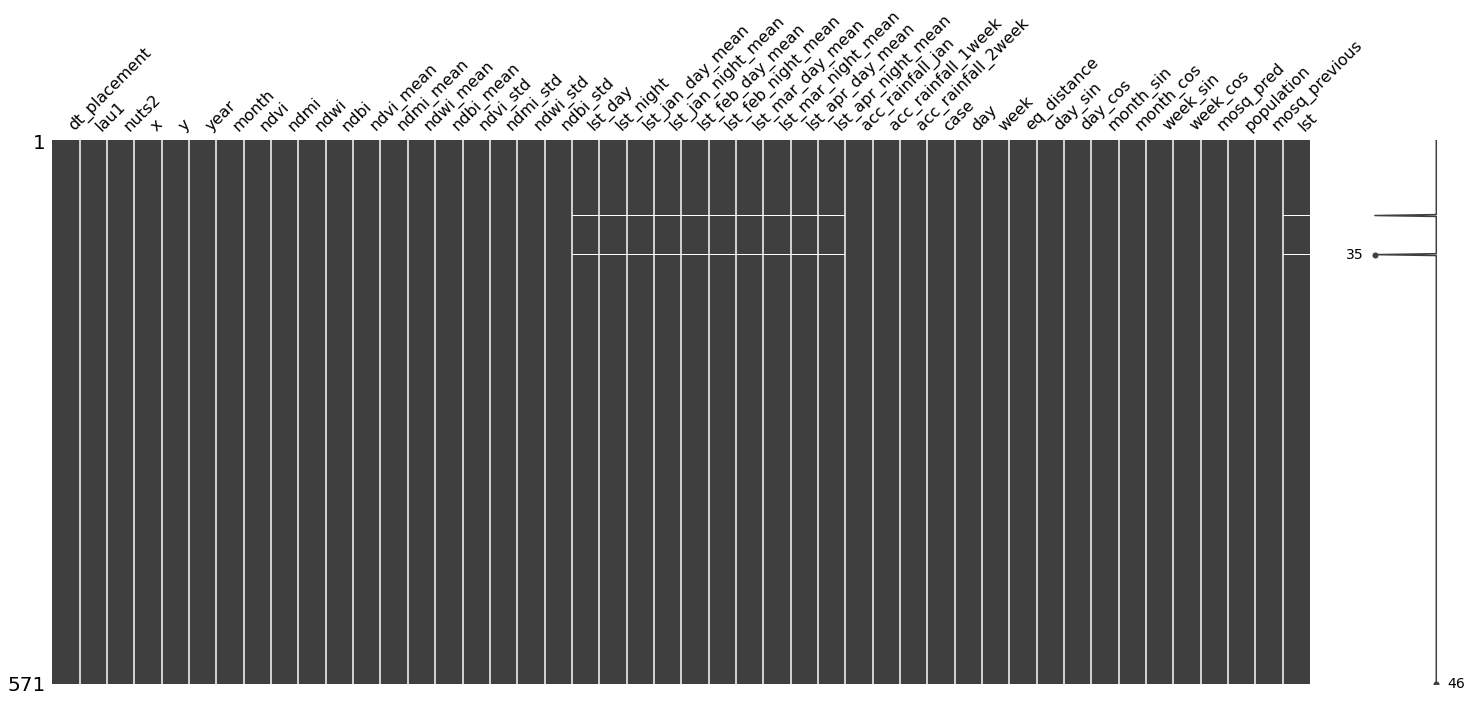

In [59]:
missingno.matrix(dataset)

In [60]:
dataset['case'].value_counts()

0    571
Name: case, dtype: int64

In [61]:
dataset.case.sum()

0

In [62]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [63]:
dataset = convert_multiple_cases(dataset)

In [64]:
dataset['case'].value_counts()

0    571
Name: case, dtype: int64

In [65]:
dataset.case.sum()

0

In [66]:
cols = dataset.columns

In [67]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'mosq_pred', 'population',
       'mosq_previous', 'lst'],
      dtype='object')

In [68]:
len(cols)

46

In [69]:
# check columns

In [70]:
rearranged_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'population',
                 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [71]:
len(rearranged_columns)

46

In [72]:
dataset = dataset[rearranged_columns].copy()

In [73]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,11.79324,45.35865,2023-09-01,veneto,abano terme,1,9,35,2023,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,"19,349",46.86670,0.368637,0.061493,-0.335046,-0.061493,0.500961,0.213121,-0.413388,-0.213121,0.000000,0.000000,0.000000,0.000000,24.590,29.53,19.650,7.626000,0.600000,8.080000,-0.791538,18.365714,6.326364,21.500769,6.950000,88.565837,104.261956,1565.197734,19,0,0
1,12.04199,45.06525,2023-09-01,veneto,adria,1,9,35,2023,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,"20,233",46.64640,0.329892,0.006074,-0.303029,-0.006074,0.452057,0.107604,-0.413797,-0.107604,0.128406,0.120407,0.098023,0.120407,23.994,28.93,19.058,6.377211,0.808571,8.476395,-1.590923,16.728553,4.271543,21.836459,5.637644,33.568078,35.942247,1585.829922,19,0,0
2,10.77673,45.55680,2023-09-01,veneto,affi,1,9,35,2023,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,"2,297",46.81410,0.353597,0.073092,-0.332336,-0.073092,0.468483,0.136305,-0.403213,-0.136305,0.129653,0.068415,0.093486,0.068415,29.590,33.49,25.690,5.821667,0.738000,8.631538,0.720667,17.207647,3.983750,18.918421,6.878889,195.303170,213.205983,1584.392692,26,0,0
3,11.96539,45.17531,2023-09-01,veneto,agna,1,9,35,2023,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,"3,400",46.73306,0.320171,0.025688,-0.319857,-0.025688,0.465004,0.142796,-0.417618,-0.142796,0.128642,0.105475,0.092688,0.105475,23.220,28.53,17.910,4.870000,0.610000,7.752222,-2.034615,15.791176,4.124000,21.578571,5.119231,28.383700,31.619082,1532.337837,24,0,0
4,12.04755,46.30297,2023-09-01,veneto,agordo,1,9,35,2023,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,"4,249",47.84463,0.741232,0.323687,-0.627098,-0.323687,0.640572,0.351151,-0.508889,-0.351151,0.061364,0.054556,0.084401,0.054556,15.740,20.49,10.990,1.921429,-4.077692,5.623333,-2.298000,9.285385,-0.998333,11.544545,0.444545,66.013478,101.374931,1535.846290,18,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,11.13372,45.36071,2023-09-01,veneto,zevio,1,9,35,2023,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,"14,413",46.70711,0.385979,0.108018,-0.330255,-0.108018,0.454926,0.103473,-0.389330,-0.103473,0.067725,0.044294,0.047104,0.044294,30.350,36.34,24.360,6.701364,-0.852020,8.699500,-1.098088,18.977232,4.798462,21.552981,6.338254,122.043310,142.912284,1394.040558,23,0,0
567,11.35805,45.34777,2023-09-01,veneto,zimella,1,9,35,2023,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,"4,834",46.74854,0.243030,-0.039182,-0.288759,0.039182,0.348664,0.074104,-0.336464,-0.074104,0.153808,0.104715,0.100736,0.104715,32.380,39.17,25.590,5.886667,-0.212500,9.545000,-1.560588,19.420000,3.671667,23.106923,6.186364,92.196254,111.336172,1414.350506,41,0,0
568,12.17878,46.38835,2023-09-01,veneto,zoppe da cadore,1,9,35,2023,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,265,47.96042,0.605675,0.281434,-0.513935,-0.281434,0.416134,0.311667,-0.320716,-0.311667,0.085287,0.014409,0.080532,0.014409,13.490,16.25,10.730,-1.975000,-5.546000,3.270000,-3.660000,6.151818,-1.397692,6.535000,-1.456154,72.043143,115.127452,1569.161136,26,0,0
569,11.49430,45.43798,2023-09-01,veneto,zovencedo,1,9,35,2023,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,796,46.86928,0.681957,0.239500,-0.560083,-0.239500,0.273585,0.297118,-0.166500,-0.297118,0.000000,0.000000,0.000000,0.000000,29.270,32.75,25.790,6.098571,1.215455,8.158333,1.778000,15.2029

### Add geomorphological features ###

In [74]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [75]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.022653999703851423
Max distance: 1.374605764363292


In [76]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [77]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,11.79324,45.35865,2023-09-01,veneto,abano terme,1,9,35,2023,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,"19,349",46.86670,0.368637,0.061493,-0.335046,-0.061493,0.500961,0.213121,-0.413388,-0.213121,0.000000,0.000000,0.000000,0.000000,24.590,29.53,19.650,7.626000,0.600000,8.080000,-0.791538,18.365714,6.326364,21.500769,6.950000,88.565837,104.261956,1565.197734,19,0,0,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.0,1.063084
1,12.04199,45.06525,2023-09-01,veneto,adria,1,9,35,2023,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,"20,233",46.64640,0.329892,0.006074,-0.303029,-0.006074,0.452057,0.107604,-0.413797,-0.107604,0.128406,0.120407,0.098023,0.120407,23.994,28.93,19.058,6.377211,0.808571,8.476395,-1.590923,16.728553,4.271543,21.836459,5.637644,33.568078,35.942247,1585.829922,19,0,0,6701.380530,1644.125334,2,145.603087,-1.354496,180.070371,0.0,1.206604
2,10.77673,45.55680,2023-09-01,veneto,affi,1,9,35,2023,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,"2,297",46.81410,0.353597,0.073092,-0.332336,-0.073092,0.468483,0.136305,-0.403213,-0.136305,0.129653,0.068415,0.093486,0.068415,29.590,33.49,25.690,5.821667,0.738000,8.631538,0.720667,17.207647,3.983750,18.918421,6.878889,195.303170,213.205983,1584.392692,26,0,0,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.0,1.815834
3,11.96539,45.17531,2023-09-01,veneto,agna,1,9,35,2023,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,"3,400",46.73306,0.320171,0.025688,-0.319857,-0.025688,0.465004,0.142796,-0.417618,-0.142796,0.128642,0.105475,0.092688,0.105475,23.220,28.53,17.910,4.870000,0.610000,7.752222,-2.034615,15.791176,4.124000,21.578571,5.119231,28.383700,31.619082,1532.337837,24,0,0,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.0,3.769479
4,12.04755,46.30297,2023-09-01,veneto,agordo,1,9,35,2023,0.201299,0.97953,-1.0,-1.836970e-16,-0.845596,-0.533823,"4,249",47.84463,0.741232,0.323687,-0.627098,-0.323687,0.640572,0.351151,-0.508889,-0.351151,0.061364,0.054556,0.084401,0.054556,15.740,20.49,10.990,1.921429,-4.077692,5.623333,-2.298000,9.285385,-0.998333,11.544545,0.444545,66.013478,101.374931,1535.846290,18,0,0,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.0,2.289867


<AxesSubplot:>

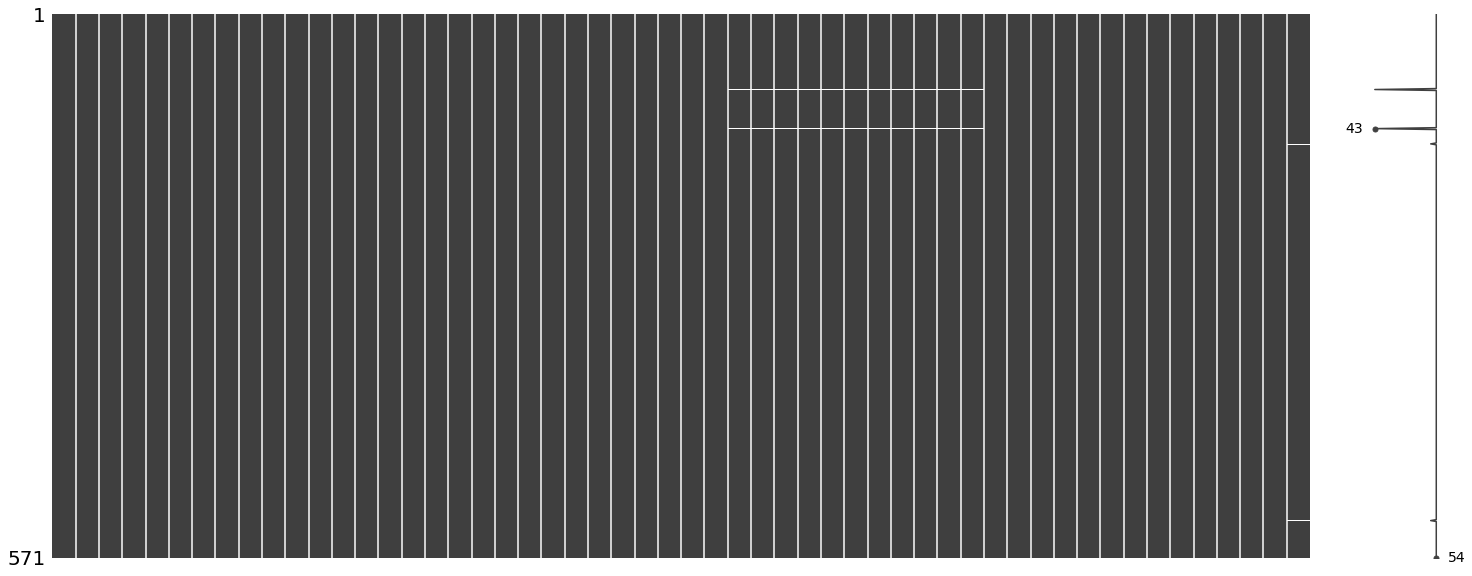

In [78]:
missingno.matrix(dataset)

In [79]:
cols = dataset.columns
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'population', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi',
       'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std',
       'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night',
       'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
       'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
       'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'mosq_pred', 'mosq_previous',
       'case', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m'],
      dtype='object')

In [80]:
len(cols)

54

In [81]:
rearranged_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'population',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case']

In [82]:
len(rearranged_columns)

54

In [83]:
dataset = dataset[rearranged_columns]

### Add Landcover features ###

In [84]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
landcover.columns = landcover.columns.str.lower()

In [85]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [86]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [87]:
data_years = dataset['year'].unique().tolist()

In [88]:
for year in data_years:
    frame_name = f'dataset_{year}'
    locals()[frame_name] = dataset.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [89]:
for year in data_years:
    data_name = f'dataset_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_part_{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = df_lulc.append(locals()[lc_name].iloc[[index]])

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2023
Min distance: 0.022654405382625
Max distance: 1.3746060850366295


In [90]:
dataset_final = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_part_{year}'
    dataset_final = pd.concat([dataset_final, locals()[merged_name]], ignore_index=True)

<AxesSubplot:>

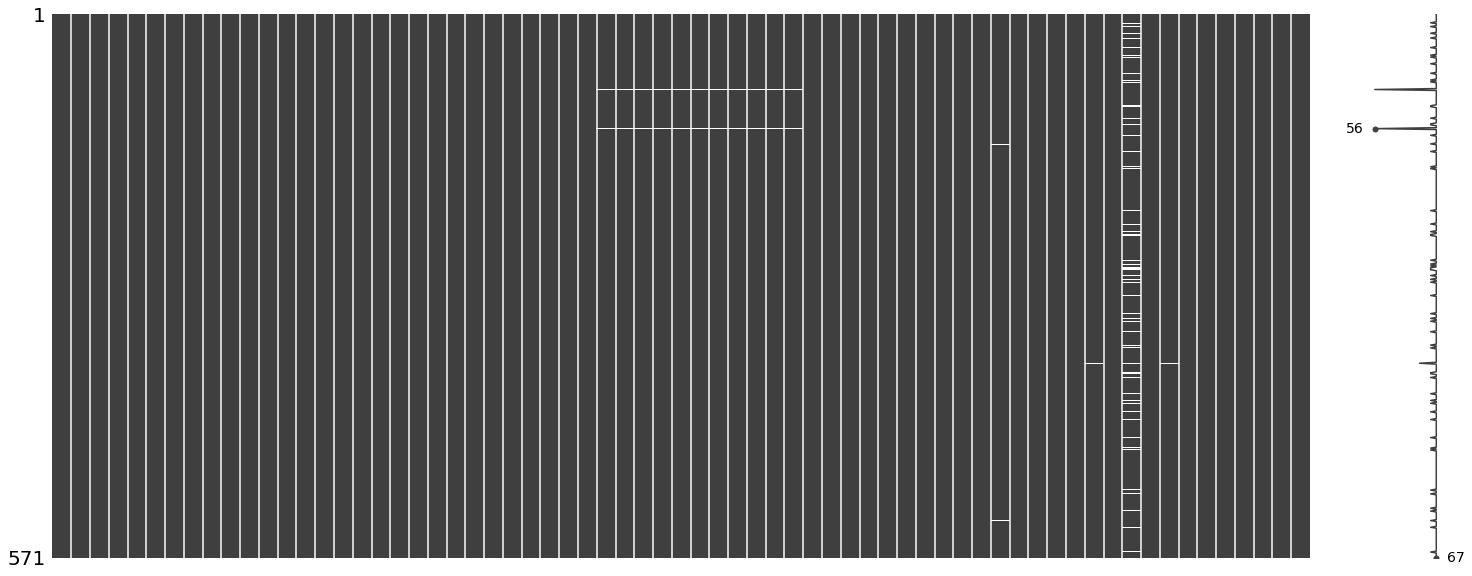

In [91]:
missingno.matrix(dataset_final)

In [92]:
cols = dataset_final.columns
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'population', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi',
       'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std',
       'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night',
       'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
       'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
       'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case', 'lc_prop1',
       'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment', 'lc_prop3',
       'lc_prop3_assessment', 'lc_type1', 'lc_type2', 'lc_typ

In [93]:
len(cols)

67

In [94]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'population',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 
       'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 
       'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 
       'lc_prop1', 'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment', 
       'lc_prop3', 'lc_prop3_assessment', 'lc_type1', 'lc_type2', 'lc_type3', 
       'lc_type4', 'lc_type5', 'lw', 'qc', 'mosq_pred', 'mosq_previous', 'case']

In [95]:
len(rearranged)

67

In [96]:
dataset_final = dataset_final[rearranged]

In [97]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_{YEAR}-{MONTH}-{PERIOD}.csv", encoding = enc, index = False)